In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display
import plotly.io as pio
import pickle 
import os
from pathlib import Path
from scipy import stats
import numpy as np
import datetime
import numpy as np
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pandas.tseries.holiday import USFederalHolidayCalendar
from typing import Literal
import importlib

**This notebook is primarily focusssed on modelling the conditional mean and variance using ARMA - GJR - GARCH model** <br>

ARMA models the conditonal mean <br>
GJR - GARCH models the asymmetric vols on +/-same shock

### Why are we modelling conditional mean and variance?

 Raw mean and variance assumes iid across time, but financial data violates it.
 1. Has volatility clustering
 2. Autocorrelation to recent past
 3. Asymmetric effect (Why GJR GARCH is used)

And also, if you pass in raw mean and vairance into copulas- it breaks. Why?
1. Copulas are modelling changing dependence- which needs conditioned variance and mean
2. **VIOLATES SKLARs THEOREM: SKLARS theorem assumes marginals transaform, F1, F2, etc. iid random varianble into uniform variables, Ui ~ Uniform(0,1). If vols are clustered, observations within same period are serially dependent, violating iid assumption and also distorts the PIT,prob integral transform** 


## Read Data

In [2]:
current_path = Path.cwd()
try:
    project_root = next(p for p in current_path.parents if p.name == "CommodityProject")
except StopIteration:
    print(Path.cwd())
except e as exception:
    print(e)

In [3]:
%cd $project_root

c:\Users\BudgetGamer\Projects\Ian\CommodityProject


In [ ]:
#'rb' (write binary) mode and dump the dict into it
with open("SystemicRiskCopulaProject/Data/cleaned_dfs.pkl", "rb") as f:
    dfs = pickle.load(f)

In [5]:
import SystemicRiskCopulaProject.Scripts.BasicOperations as basic
import pandas as pd

In [6]:
dfs.keys()

dict_keys(['NG', 'Copper', 'Brent', 'Corn', 'WTI', 'Cattle', 'Cocoa'])

In [35]:
'''
# Remove holidays:
for _name, _df in dfs.items():
    #dfs[_name]= basic.removeHolidays(_df)

print("cwd:", os.getcwd())
print("dfs type:", type(dfs))
print("keys:", list(dfs.keys())[:5])

with open("cleaned_dfs.pkl", "wb") as f:
    pickle.dump(dfs, f)
    f.flush()
    os.fsync(f.fileno())

print("size:", os.path.getsize("cleaned_dfs.pkl"))
'''

'\n# Remove holidays:\nfor _name, _df in dfs.items():\n    #dfs[_name]= basic.removeHolidays(_df)\n\nprint("cwd:", os.getcwd())\nprint("dfs type:", type(dfs))\nprint("keys:", list(dfs.keys())[:5])\n\nwith open("cleaned_dfs.pkl", "wb") as f:\n    pickle.dump(dfs, f)\n    f.flush()\n    os.fsync(f.fileno())\n\nprint("size:", os.path.getsize("cleaned_dfs.pkl"))\n'

## ARMA modelling

$$R_{i,t} = \alpha_i + \sum_{j=1}^{p} \beta_{i,j} R_{i,t-j} + \sum_{k=1}^{q} \zeta_{i,k} \epsilon_{i,t-k} + \epsilon_{i,t}$$

$p$: The lag order of the autoregressive process (how many past time periods are included).<br>$\beta_{i,j}$: The coefficient measuring the persistence/impact of past returns $j$ periods ago on the current return.<br>$R_{i,t-j}$: The historical return of the asset at lag $t-j$. <br>
$q$: The lag order of the moving average process.<br>$\zeta_{i,k}$: The coefficient measuring the sensitivity to unexpected market shocks $k$ periods ago.<br>$\epsilon_{i,t-k}$: The past unpredicted residual or unexpected shock (innovation) from $k$ periods ago.<br>$\epsilon_{i,t}$ residuals gets passed onto GJR-GARCH assuming non-constant vol under normal distribution,ie, heteroskedasity

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

def arma_bic_grid_search(series, series_name="Commodity", max_p=3, max_q=3):
    """
    Performs grid search over ARMA(p, q) models up to max_p and max_q.
    Selects optimal model by BIC, plots a heatmap, and runs a Ljung-Box test.
    """
    p_values = list(range(max_p + 1))
    q_values = list(range(max_q + 1))
    
    bic_matrix = pd.DataFrame(index=p_values, columns=q_values, dtype=float)
    aic_matrix = pd.DataFrame(index=p_values, columns=q_values, dtype=float)
    
    fitted_models = {}
    best_bic = np.inf
    best_order = (0, 0)
    
    # Grid search loop
    for p in p_values:
        for q in q_values:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore")
                    # Fit ARMA(p, q) with constant intercept (trend='c')
                    model = ARIMA(series, order=(p, 0, q), trend='c')
                    res = model.fit()
                    
                    bic_val = res.bic
                    aic_val = res.aic
                    
                    bic_matrix.loc[p, q] = bic_val
                    aic_matrix.loc[p, q] = aic_val
                    fitted_models[(p, q)] = res
                    
                    if bic_val < best_bic:
                        best_bic = bic_val
                        best_order = (p, q)
            except Exception:
                bic_matrix.loc[p, q] = np.nan
                aic_matrix.loc[p, q] = np.nan

    best_model = fitted_models[best_order]
    
    # -------------------------------------------------------------
    # 1. Visualization: BIC Heatmap Surface
    # -------------------------------------------------------------
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        bic_matrix.astype(float),
        annot=True,
        fmt=".1f",
        cmap="YlGnBu_r",  # Darker blue = lower (better) BIC
        cbar_kws={'label': 'BIC Value'}
    )
    plt.title(f"ARMA(p, q) BIC Selection Grid — {series_name}\nOptimal: ARMA{best_order}")
    plt.xlabel("MA Order (q)")
    plt.ylabel("AR Order (p)")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------
    # 2. Diagnostic: Ljung-Box Test on Residuals
    # -------------------------------------------------------------
    residuals = best_model.resid
    
    # Check 10 lags as performed in the paper
    lb_df = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_stat = lb_df['lb_stat'].values[0]
    lb_pval = lb_df['lb_pvalue'].values[0]
    
    print("=" * 60)
    print(f"Results for {series_name}:")
    print(f"Optimal Model : ARMA{best_order} with Minimum BIC = {best_bic:.2f}")
    print(f"Ljung-Box Test (Lag 10): Stat = {lb_stat:.4f}, p-value = {lb_pval:.4f}")
    if lb_pval > 0.05:
        print("Conclusion    : Pass. No serial correlation remaining (p > 0.05).")
    else:
        print("Conclusion    : Warning. Residual serial correlation detected.")
    print("=" * 60)
    
    return best_order, best_model, residuals, bic_matrix

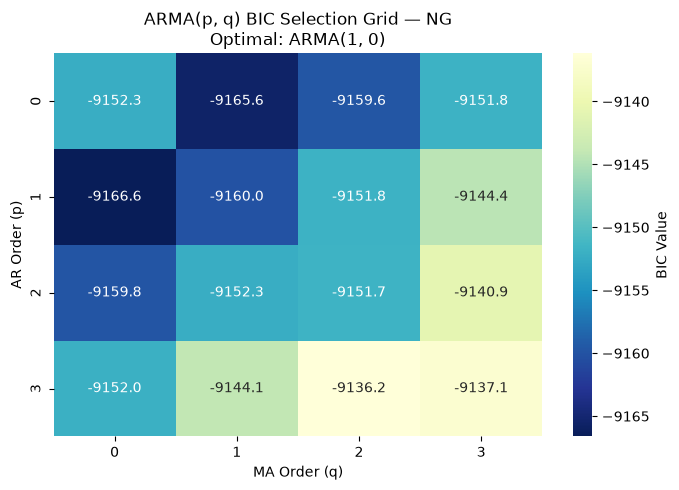

Results for NG:
Optimal Model : ARMA(1, 0) with Minimum BIC = -9166.62
Ljung-Box Test (Lag 10): Stat = 22.2745, p-value = 0.0138
Conclusion    : Warning. Residual serial correlation detected.


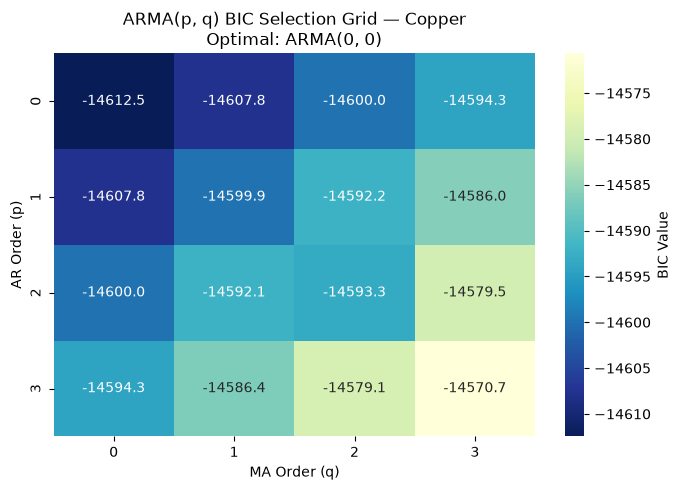

Results for Copper:
Optimal Model : ARMA(0, 0) with Minimum BIC = -14612.46
Ljung-Box Test (Lag 10): Stat = 10.9528, p-value = 0.3612
Conclusion    : Pass. No serial correlation remaining (p > 0.05).


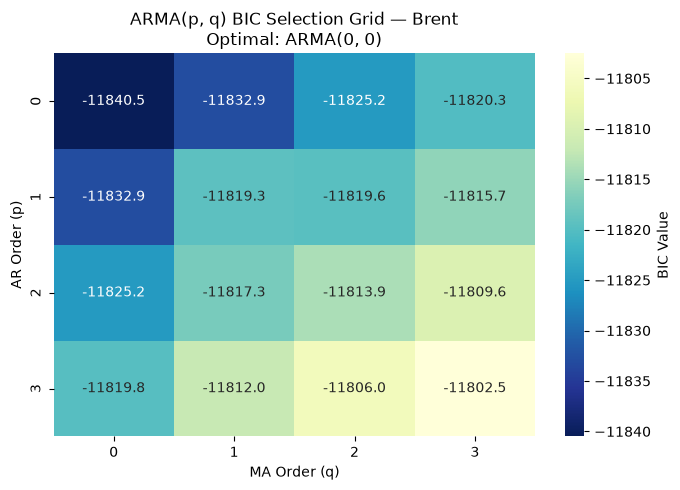

Results for Brent:
Optimal Model : ARMA(0, 0) with Minimum BIC = -11840.50
Ljung-Box Test (Lag 10): Stat = 25.2027, p-value = 0.0050
Conclusion    : Warning. Residual serial correlation detected.


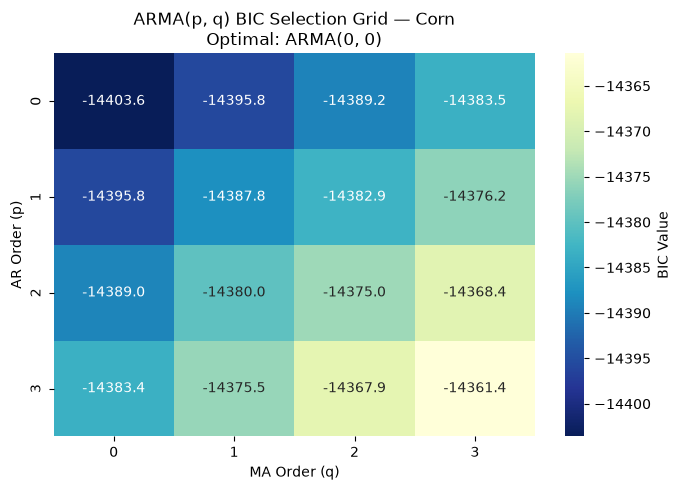

Results for Corn:
Optimal Model : ARMA(0, 0) with Minimum BIC = -14403.61
Ljung-Box Test (Lag 10): Stat = 11.0843, p-value = 0.3510
Conclusion    : Pass. No serial correlation remaining (p > 0.05).


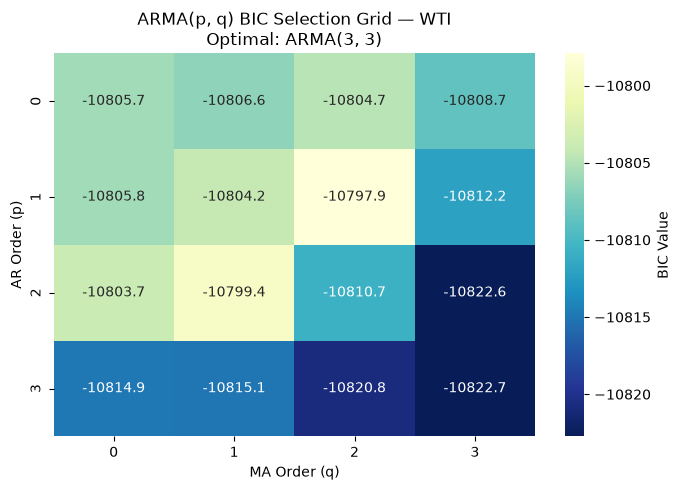

Results for WTI:
Optimal Model : ARMA(3, 3) with Minimum BIC = -10822.74
Ljung-Box Test (Lag 10): Stat = 18.5447, p-value = 0.0464
Conclusion    : Warning. Residual serial correlation detected.


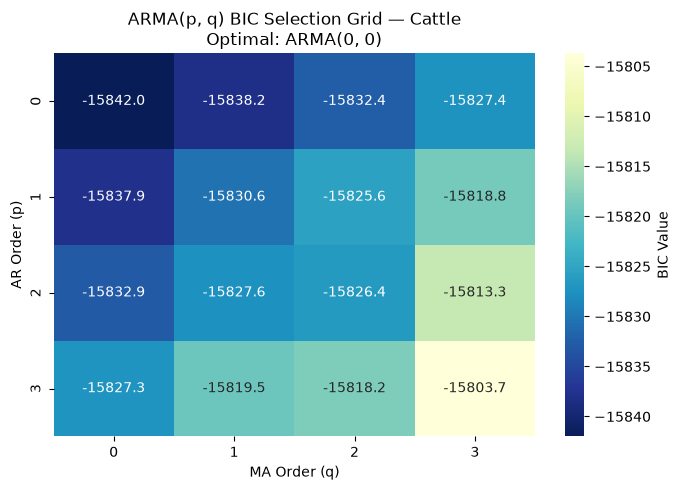

Results for Cattle:
Optimal Model : ARMA(0, 0) with Minimum BIC = -15842.00
Ljung-Box Test (Lag 10): Stat = 28.6426, p-value = 0.0014
Conclusion    : Warning. Residual serial correlation detected.


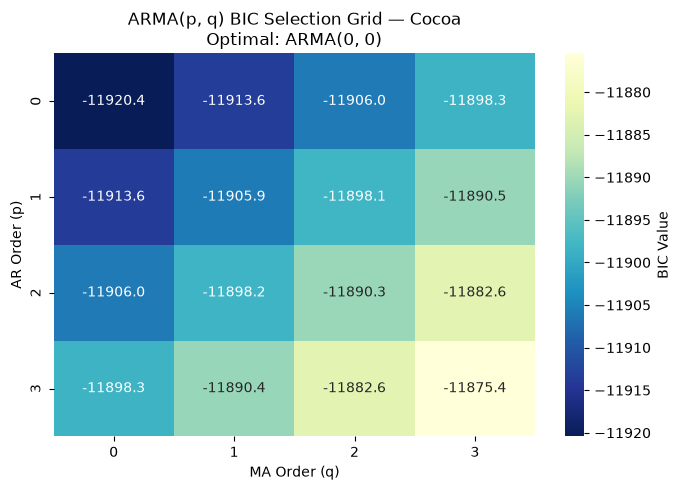

Results for Cocoa:
Optimal Model : ARMA(0, 0) with Minimum BIC = -11920.44
Ljung-Box Test (Lag 10): Stat = 8.0682, p-value = 0.6222
Conclusion    : Pass. No serial correlation remaining (p > 0.05).


In [37]:
arma_dict =dict()
for _name, _df in dfs.items():

    best_order, model_fit, eps_residuals, bic_table = arma_bic_grid_search(
        series= _df['Log_Returns'], 
        series_name=_name, 
        max_p=3, 
        max_q=3
    )
    arma_dict[_name] = [best_order, model_fit, eps_residuals, bic_table]

#### Plottting ACF plot for residuals

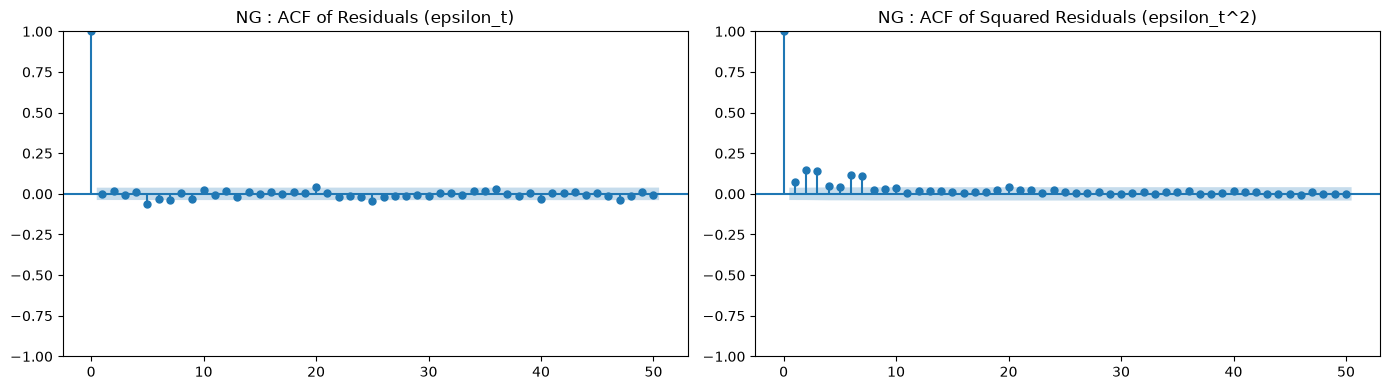

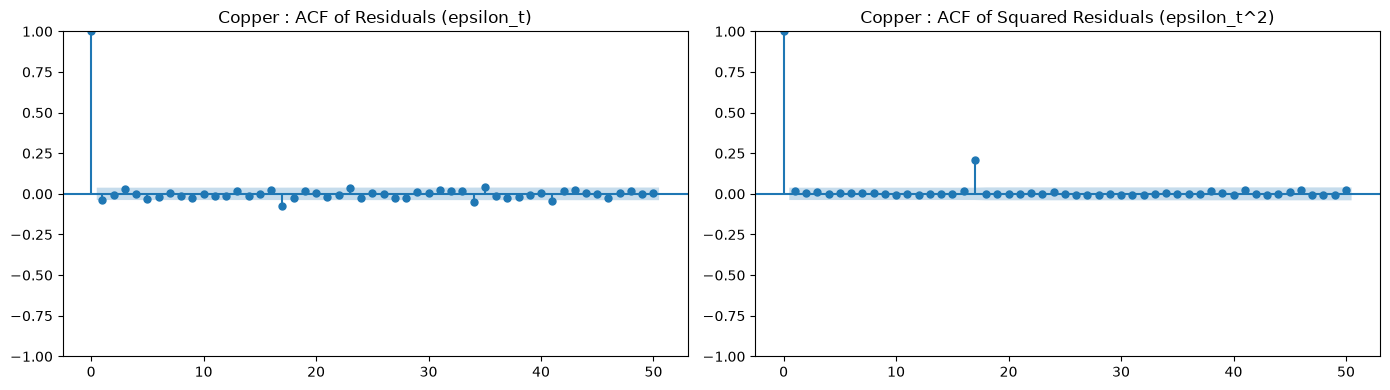

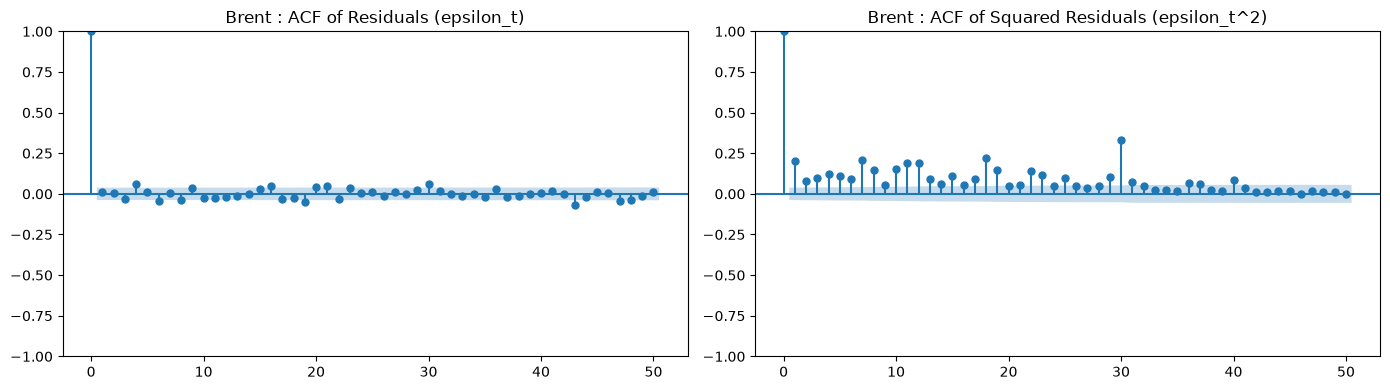

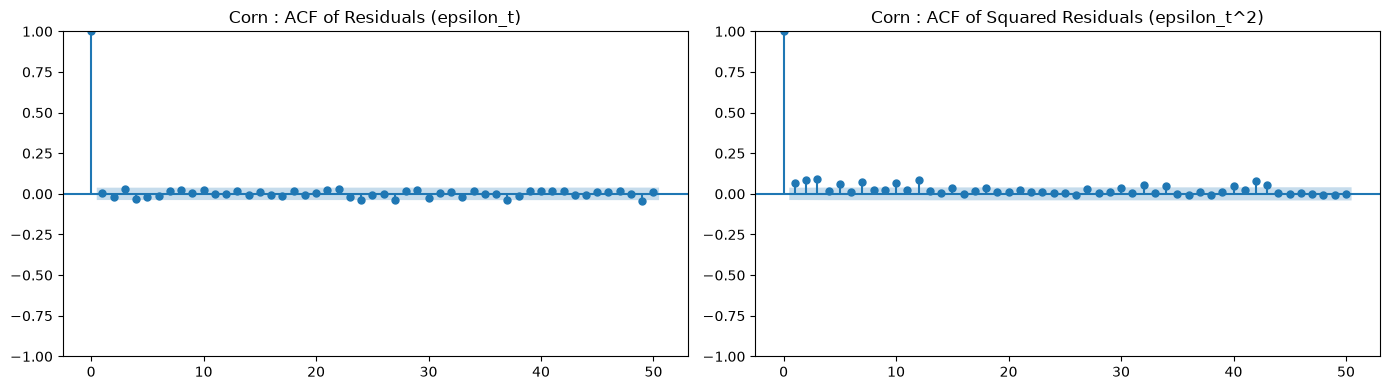

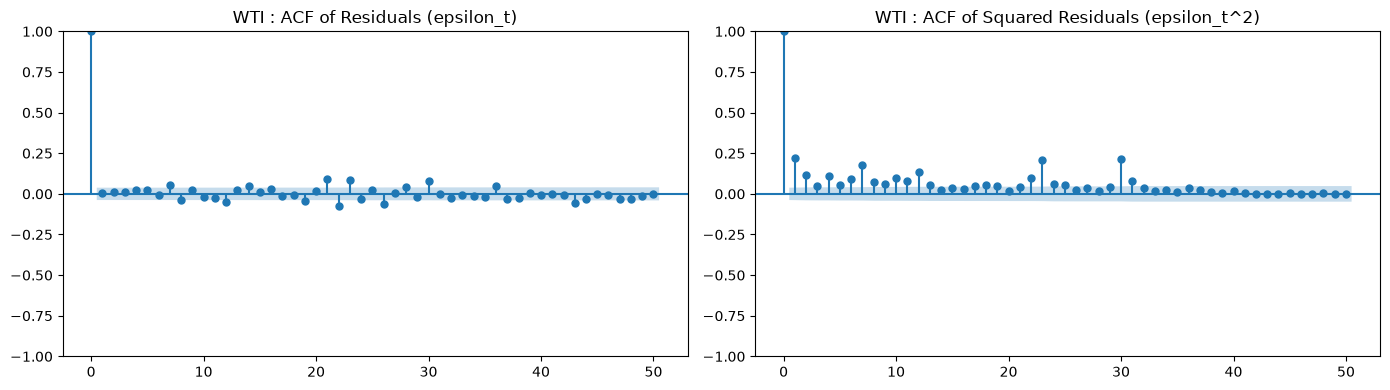

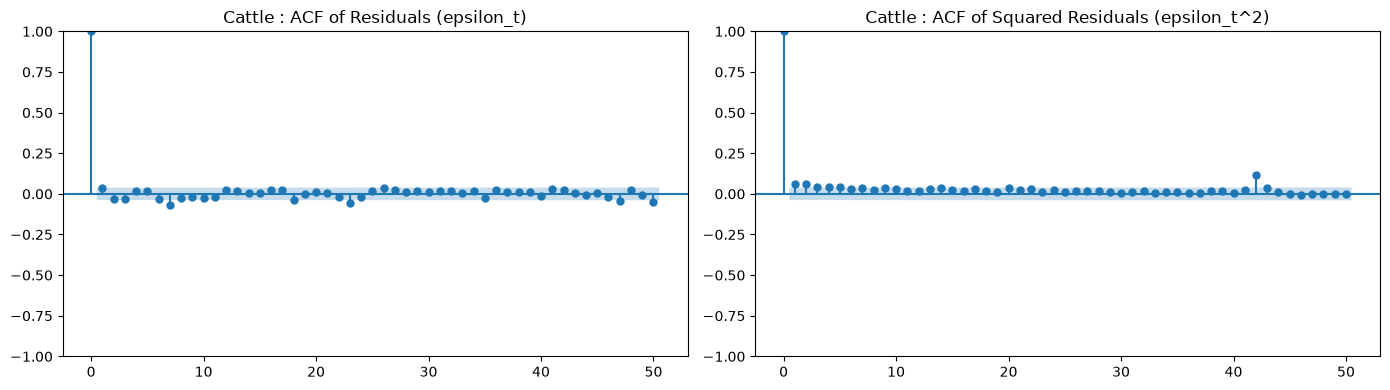

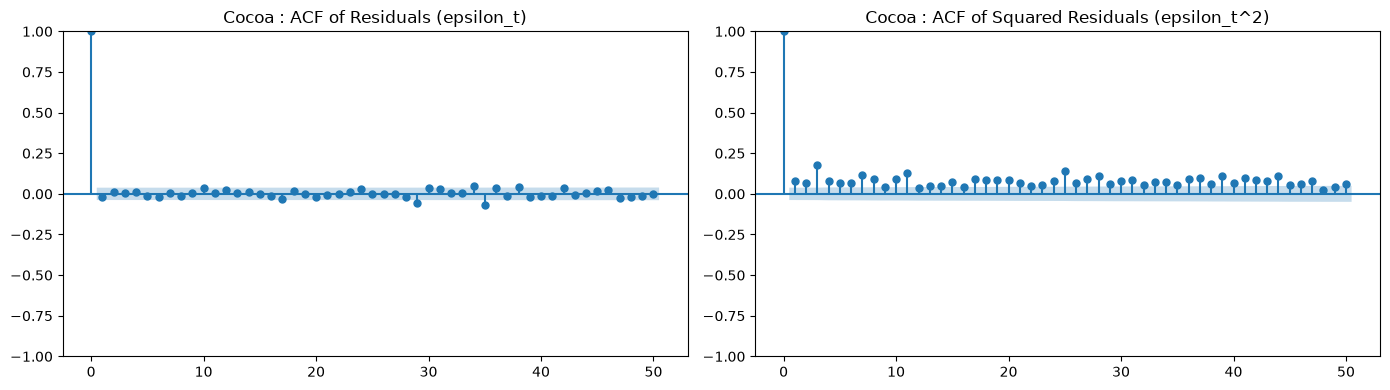

In [39]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
for _name, _val in arma_dict.items():
    clean_residuals = _val[2]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(clean_residuals, lags=50, ax=ax[0], title=f"{_name} : ACF of Residuals (epsilon_t)")
    plot_acf(clean_residuals**2, lags=50, ax=ax[1], title=f"{_name} : ACF of Squared Residuals (epsilon_t^2)")
    plt.tight_layout()
    plt.show()

From the plots, its inferred that the autocrrelation exist not in mean but in variance. Ljung-box test failed in some because it assumed homoskedasity while the data is heteroskedastic.<br>

### Next step: <br>
1. Find the conditional variance and figure out the standardized residual and test whether its in Skewed-t 
$$\eta_{i,t} = \frac{\epsilon_{i,t}}{\sigma_{i,t}} \sim \text{Skewed-}t(\nu, \psi)$$

In [27]:
clean_residuals

2      -0.026019
3      -0.006246
4       0.017871
5      -0.000190
6      -0.000190
          ...   
3885   -0.028981
3886   -0.010726
3887    0.009831
3888    0.056290
3889    0.058493
Length: 3888, dtype: float64